In [1]:
import pandas as pd
import matplotlib.pyplot as plt

volume_df = pd.read_csv("europe_lng_volumes.csv")
volume_df["period"] = pd.to_datetime(volume_df["period"])

In [5]:
germany_df = volume_df[volume_df["country"] == "Germany"]

In [6]:
germany_df.head()

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units,country
85,2022-01-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
86,2022-02-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
87,2022-03-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
88,2022-04-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
89,2022-05-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany


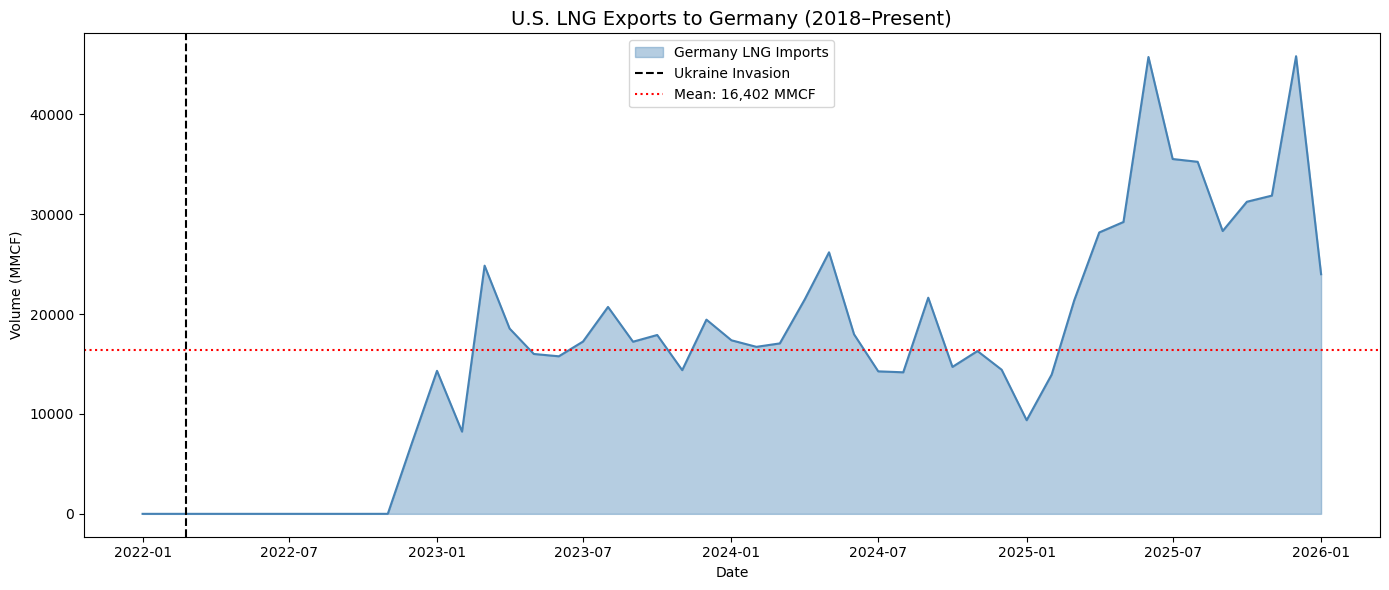

In [8]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(germany_df["period"], germany_df["value"],
                alpha=0.4, color="steelblue", label="Germany LNG Imports")
ax.plot(germany_df["period"], germany_df["value"],
                color="steelblue", linewidth=1.5)

ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", linewidth=1.5, label="Ukraine Invasion")
ax.axhline(germany_df["value"].mean(), color="red", linestyle=":", linewidth=1.5, label=f"Mean: {germany_df['value'].mean():,.0f} MMCF")

ax.set_title("U.S. LNG Exports to Germany (2018–Present)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (MMCF)")
ax.legend()
plt.tight_layout()
plt.savefig("germany_lng_imports.png", dpi=150)
plt.show()

In [11]:
germany_pre = germany_df[germany_df["period"] < "2022-01-24"]
germany_post = germany_df[germany_df["period"] > "2022-01-24"]

print("Pre-invasion avg German Monthly Volume (MMCF):", germany_pre["value"].mean())
print("Post-invasion avg German Monthly Volume (MMCF):", germany_post["value"].mean())

Pre-invasion avg German Monthly Volume (MMCF): 0.0
Post-invasion avg German Monthly Volume (MMCF): 16743.791666666668


In [14]:
germany_pre_total = germany_pre.groupby("period")["value"].sum()
germnay_post_total = germany_post.groupby("period")["value"].sum()

print("Pre-invasion average monthly Europe total (MMCF):", germany_pre_total.mean())
print("Post-invasion average monthly Europe total (MMCF):", germany_post_total.mean())

Pre-invasion average monthly Europe total (MMCF): 0.0
Post-invasion average monthly Europe total (MMCF): 16743.791666666668


In [17]:
## because pre invasion germany is zero, not practical to obtain a ratio of change.

print(f"Pre-invasion total volume: {germany_pre['value'].sum():,.0f} MMCF")
print(f"Post-invasion total volume: {germany_post['value'].sum():,.0f} MMCF")
print(f"Post-invasion monthly average: {germany_post['value'].mean():,.0f} MMCF")
print(f"First recorded import month: {germany_post['period'].min()}")

Pre-invasion total volume: 0 MMCF
Post-invasion total volume: 803,702 MMCF
Post-invasion monthly average: 16,744 MMCF
First recorded import month: 2022-02-01 00:00:00


In [18]:
germany_post[germany_post["period"].dt.year == 2022].sort_values("period")

,period,duoarea,area-name,product,product-name,process,process-name,series,series-description,value,units,country
86,2022-02-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
87,2022-03-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
88,2022-04-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
89,2022-05-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
90,2022-06-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
91,2022-07-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
92,2022-08-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
93,2022-09-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
94,2022-10-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,0,MMCF,Germany
95,2022-11-01,NUS-NGM,DEU,EPG0,Natural Gas,EVE,Exports by Vessel,NGM_EPG0_EVE_NUS-NGM_MMCF,U.S. Liquefied Natural Gas Exports by Vessel t...,1,MMCF,Germany


In [19]:
germany_post_real = germany_df[germany_df["period"] >= "2022-12-01"]

print(f"Post-infrastructure monthly average: {germany_post_real['value'].mean():,.0f} MMCF")
print(f"Months of data: {len(germany_post_real)}")

Post-infrastructure monthly average: 21,150 MMCF
Months of data: 38


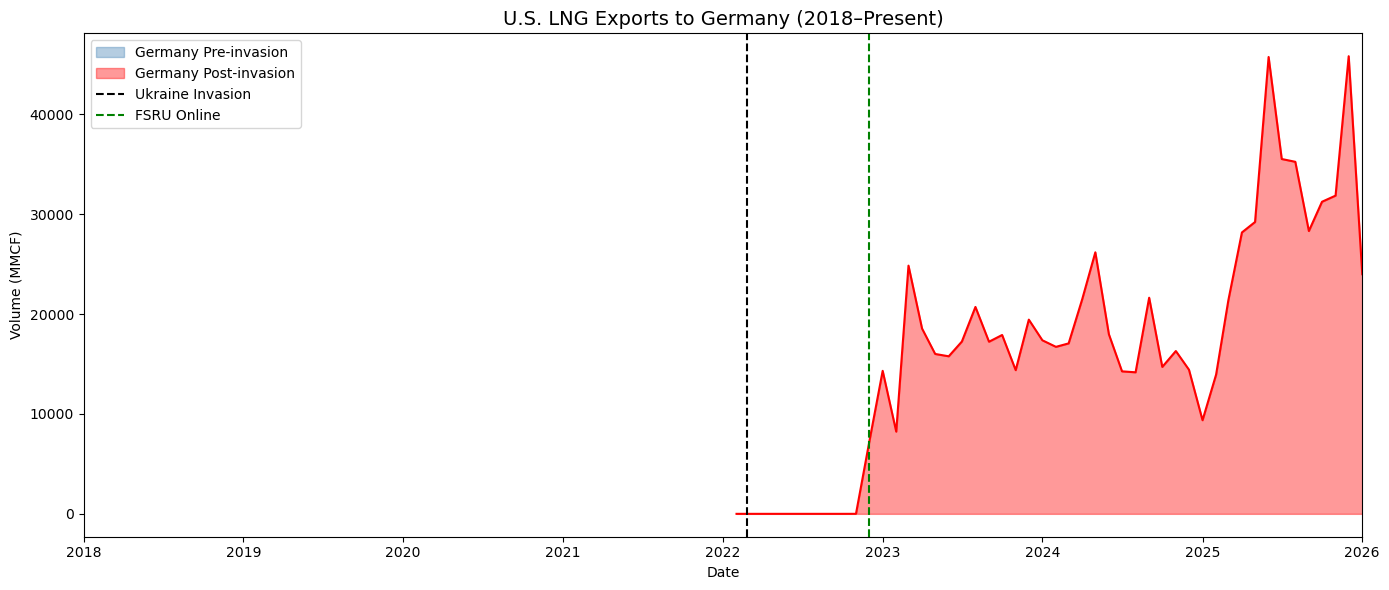

In [24]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(germany_pre_total.index, germany_pre_total.values,
                alpha=0.4, color="steelblue", label="Germany Pre-invasion")
ax.plot(germany_pre_total.index, germany_pre_total.values,
                color="steelblue", linewidth=1.5)

ax.fill_between(germany_post_total.index, germany_post_total.values,
                alpha=0.4, color="red", label="Germany Post-invasion")
ax.plot(germany_post_total.index, germany_post_total.values,
                color="red", linewidth=1.5)

ax.axvline(pd.Timestamp("2022-02-24"), color="black", linestyle="--", linewidth=1.5, label="Ukraine Invasion")
ax.axvline(pd.Timestamp("2022-12-01"), color="green", linestyle="--", linewidth=1.5, label="FSRU Online")

ax.set_title("U.S. LNG Exports to Germany (2018–Present)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Volume (MMCF)")
ax.legend()
ax.set_xlim(pd.Timestamp("2018-01-01"), germany_df["period"].max())
plt.tight_layout()
plt.savefig("germany_lng_imports.png", dpi=150)
plt.show()